## Preprocessing

Based on the findings from the exploratory data analysis, several preprocessing steps are applied to prepare the dataset for model training. These include removing null values and extreme outliers, correcting malformed escape tokens, and cleaning the email text by removing URLs, HTML tags, punctuation, and other unnecessary characters. Stopwords are then removed, followed by lemmatization to reduce words to their base forms. The resulting cleaned dataset is saved to `data/processed/cleaned.csv` for use in subsequent modelling stages.


In [ ]:
# Mounting Google Drive to access the dataset. Alternatively, you may upload the dataset directly from your local storage.

from google.colab import drive
drive.mount('/content/drive')

# Change this according to where your dataset is stored.
dataset_path ="/content/drive/MyDrive/Spam-Ham Dataset/spam_Emails_data.csv"

Mounted at /content/drive


In [ ]:
# Import all required packages for the preprocessing.

import pandas as pd
import numpy as np
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Create assets folder and set plot DPI
PREPROCESSING_PLOT_DIR = "/content/assets/preprocessing_plots"
os.makedirs(PREPROCESSING_PLOT_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 150

print("Preprocessing plots folder created at:", PREPROCESSING_PLOT_DIR)

Preprocessing plots folder created at: /content/assets/preprocessing_plots


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Load the dataset and perform basic cleaning.

df = pd.read_csv(dataset_path)
print("Shape before cleaning the dataset:", df.shape)

# Drop the null values.
df.dropna(subset=["text", "label"], inplace=True)

# Encode labels Spam:1 and Ham:0
df["label_enc"] = df["label"].map({"Spam" : 1,"Ham" : 0})

# Shape after dropping null values
print("Shape after dropping null values:", df.shape)
print("First few rows of dataset:")
print(df.head())

Shape before cleaning the dataset: (193852, 2)
Shape after dropping null values: (193850, 3)
First few rows of dataset:
  label                                               text  label_enc
0  Spam  viiiiiiagraaaa\nonly for the ones that want to...          1
1   Ham  got ice thought look az original message ice o...          0
2  Spam  yo ur wom an ne eds an escapenumber in ch ma n...          1
3  Spam  start increasing your odds of success & live s...          1
4   Ham  author jra date escapenumber escapenumber esca...          0


In [ ]:
# Removing outliers at 99th percentile

# Check 99th percentile per class
print(df.groupby("label")["text"].apply(lambda x: x.str.len().quantile(0.99)))

label
Ham     19723.2
Spam    10435.5
Name: text, dtype: float64


In [ ]:
# Remove rows above 99th percentile of char length

p99 = df["text"].str.len().quantile(0.99)
before = len(df)
df = df[df["text"].str.len() <= p99]
print(f"Removed {before - len(df)} outlier rows")
print("Remaining rows:", len(df))

Removed 1939 outlier rows
Remaining rows: 191911


In [ ]:
# Preprocess the dataset by removing nulls and outliers, cleaning the text,
# fixing escape tokens, removing stopwords, applying lemmatization,
# and saving the cleaned data for modelling.

def clean_text(text):
    # lowercase
    text = text.lower()

    # fix broken escape tokens
    text = re.sub(r'[a-z]escapenumber[a-z]?', ' escapenumber ', text)
    text = re.sub(r'[a-z]escapelong[a-z]?', ' escapelong ', text)

    # collapse repeated characters (viiiiiiagraaaa → viagra)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # remove HTML tags and artifacts
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\b(img|src|href|alt|div|span|nbsp|http|www|html|css)\b', ' ', text)

    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
# test on a few samples before applying to full dataset

samples = df["text"].head(5).tolist()
for s in samples:
    print("BEFORE:", s[:150])
    print("AFTER: ", clean_text(s)[:150])
    print("-" * 60)

BEFORE: viiiiiiagraaaa
only for the ones that want to make her scream .
prodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate p
AFTER:  viagra only for the ones that want to make her scream prodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate ponce berni
------------------------------------------------------------
BEFORE: got ice thought look az original message ice operations mailto iceoperations intcx com sent friday october escapenumber escapenumber escapenumber esca
AFTER:  got ice thought look az original message ice operations mailto iceoperations intcx com sent friday october escapenumber escapenumber escapenumber esca
------------------------------------------------------------
BEFORE: yo ur wom an ne eds an escapenumber in ch ma n b e th at ma n f or h er le arn h ow here tu rn of f not ific ati ons here escapelong dy international 
AFTER:  yo ur wom an ne eds an escapenumber in ch ma n b e th at ma n f or h er le 

In [ ]:
df["text_cleaned"] = df["text"].apply(clean_text)
print("Cleaning done.")
df[["text", "text_cleaned"]].head(3)

Cleaning done.


,text,text_cleaned
0,viiiiiiagraaaa\nonly for the ones that want to...,viagra only for the ones that want to make her...
1,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom an ne eds an escapenumber in ch ma n...


In [ ]:
# Remove stopwords and apply lemmatization to reduce noise and normalize words
# into their base forms, improving the quality of the TF-IDF vocabulary.

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# keep the following words as they are spam signals identified in EDA
keep_words = {

    "no", "not", "free", "your", "you", "will", "won",


    "never", "none", "neither", "nor", "against",
    "don", "dont", "do_not", "can", "cant", "cannot",
    "shouldn", "shouldnt", "wasn", "wasnt", "weren", "werent",
    "haven", "havent", "hasn", "hasnt", "hadn", "hadnt",
    "isn", "isnt", "aren", "arent", "ain", "couldn", "couldnt",
    "wouldn", "wouldnt", "doesn", "doesnt",


    "i", "me", "my", "myself", "we", "our", "ours", "ourselves",
    "yours", "yourself", "yourselves", "he", "him", "his", "himself",
    "she", "her", "hers", "herself", "it", "its", "itself",
    "they", "them", "their", "theirs", "themselves",


    "now", "get", "win", "all", "any", "only", "more", "most",
    "off", "just", "do", "does", "did", "have", "has", "had",
    "give", "take", "make", "click", "here", "there", "when",
    "where", "why", "how", "who", "which"
}

stop_words = stop_words - keep_words

def lemmatize_text(text):
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if (w not in stop_words and len(w) > 3) or w in keep_words
    ]
    return " ".join(tokens)

In [ ]:
df["text_processed"] = df["text_cleaned"].apply(lemmatize_text)
print("Lemmatization done.")
df[["text", "text_cleaned", "text_processed"]].head(8)

Lemmatization done.


,text,text_cleaned,text_processed
0,viiiiiiagraaaa\nonly for the ones that want to...,viagra only for the ones that want to make her...,viagra only one want make her scream prodigy s...
1,got ice thought look az original message ice o...,got ice thought look az original message ice o...,thought look original message operation mailto...
2,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom an ne eds an escapenumber in ch ma n...,escapenumber here not ific here escapelong int...
3,start increasing your odds of success & live s...,start increasing your odds of success live sex...,start increasing your odds success live sexual...
4,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...,author date escapenumber escapenumber escapenu...
5,img src escapenumberd http loan co kr img emai...,escapenumberd loan co kr email im escapenumber...,escapenumberd loan email escapenumber width es...
6,attached is the weekly deal report from 10 / 1...,attached is the weekly deal report from lex ca...,attached weekly deal report carroll enron east...
7,this is the version that we created earlier th...,this is the version that we created earlier th...,version we created earlier afternoon using sho...


In [ ]:
# Sanity check

# Check for any empty strings after processing
empty = df["text_processed"].str.strip().eq("").sum()
print(f"Empty rows after processing: {empty}")

# Remove them if any
df = df[df["text_processed"].str.strip() != ""]
print("Final shape:", df.shape)

Empty rows after processing: 317
Final shape: (191594, 5)


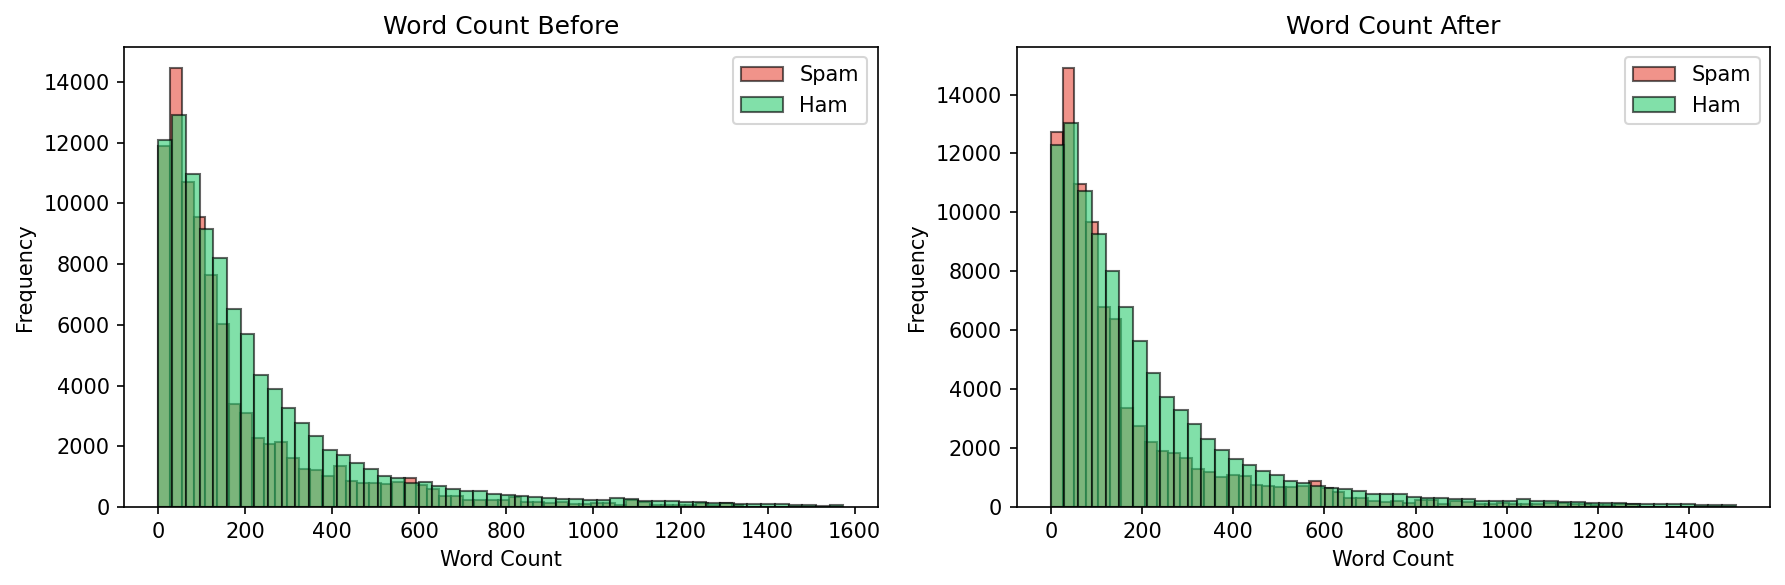

In [ ]:
# Compare average length before and after

df["len_before"] = df["text"].fillna("").astype(str).apply(lambda x: len(x.split()))
df["len_after"]  = df["text_cleaned"].fillna("").astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes,
    ["len_before", "len_after"],
    ["Word Count Before", "Word Count After"]
):
    for label, color in [("Spam", "#e74c3c"), ("Ham", "#2ecc71")]:
        subset = df[df["label"] == label][col]
        subset = subset[subset < subset.quantile(0.99)]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor="black")

    ax.set_title(title)
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSING_PLOT_DIR, "length_before_after.png"))
plt.show()

In [ ]:
# Save the preprocessed dataset

import os

# Create folder inside Colab first
SAVE_DIR = "/content/data/processed"
os.makedirs(SAVE_DIR, exist_ok=True)

# Prepare final cleaned dataframe
final_df = df[["text_cleaned", "label", "label_enc"]].copy()
final_df.rename(columns={"text_cleaned": "text"}, inplace=True)

# Save inside Colab
SAVE_PATH = os.path.join(SAVE_DIR, "cleaned.csv")
final_df.to_csv(SAVE_PATH, index=False)

print("Saved to:", SAVE_PATH)
print("Final shape:", final_df.shape)

final_df.head()

Saved to: /content/data/processed/cleaned.csv
Final shape: (191911, 3)


,text,label,label_enc
0,viagra only for the ones that want to make her...,Spam,1
1,got ice thought look az original message ice o...,Ham,0
2,yo ur wom an ne eds an escapenumber in ch ma n...,Spam,1
3,start increasing your odds of success live sex...,Spam,1
4,author jra date escapenumber escapenumber esca...,Ham,0


## Preprocessing Summary

A comprehensive preprocessing pipeline was applied to transform the raw email dataset into a clean and machine-learning-ready format.

The original dataset contained **193,852** emails. After removing **2 rows with missing values**, the dataset was examined for extreme text-length outliers identified during exploratory analysis. Using class-specific 99th percentile thresholds, **1,939 anomalous rows** were removed while preserving legitimate long-form emails.

Text normalization was then performed by cleaning unwanted characters, correcting obfuscated spam terms, and filtering noise. The engineered `escapenumber` token was intentionally retained, as numerical patterns are often informative for spam detection. Stopword removal was applied while preserving important contextual terms such as negations, pronouns, and common call-to-action words that may contribute to classification performance. Lemmatization was then used to reduce words to their root forms.

Following preprocessing, **317 rows** were removed because their contents became empty after cleaning and token filtering.

### Dataset Evolution

| Stage              | Rows Remaining | Rows Removed |
| ------------------ | -------------: | -----------: |
| Raw Dataset        |        193,852 |            - |
| Null Removal       |        193,850 |            2 |
| Outlier Removal    |        191,911 |        1,939 |
| Empty Text Removal |        191,594 |          317 |

**Final cleaned dataset shape:** `(191,594, 5)`

The processed dataset has been successfully saved to `../data/processed/cleaned.csv` and is ready for feature extraction, train-test splitting, and machine learning model development.
